<a href="https://colab.research.google.com/github/ashiyaaa121/Statistics-Essentials-for-Machine-Learning/blob/main/Week4_Statistical_Inference_Regression_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 Workshop Notebook
# Statistical Inference, Multiple Linear Regression, Hypothesis Testing and Error Analysis
This notebook brings together the key statistical ideas covered so far and shows how they appear in a real data task.

Context: Nepal tourism bookings

You will use a clean synthetic tourism dataset to answer practical questions such as:

- What does the data look like?
- Which variables are related to package spend?
- Can we build a multiple linear regression model for SpendPerPersonUSD?
- Which regression coefficients are statistically significant?
- How do confidence intervals and p values support interpretation?
- How large is the test error?
- Are residuals randomly scattered or showing model problems?


## Learning outcomes

By the end of this notebook, you should be able to:

1. Review distributions and relationships before modelling.
2. Fit a basic multiple linear regression model.
3. Interpret coefficients, confidence intervals, t statistics, and p values.
4. Understand how hypothesis testing appears inside regression output.
5. Diagnose test error using MAE, RMSE, and residual plots.
6. Use confidence intervals and hypothesis tests for business comparisons.
7. Run a simple A/B test for conversion uplift.
8. Write a business memo that combines statistical evidence and practical judgement.

## Key formulas used in this notebook

Multiple linear regression model:

$$
y_i=\beta_0+\beta_1x_{i1}+\beta_2x_{i2}+\cdots+\beta_px_{ip}+\varepsilon_i
$$

Estimated regression model:

$$
\hat{y}_i=b_0+b_1x_{i1}+b_2x_{i2}+\cdots+b_px_{ip}
$$

Residual:

$$
e_i=y_i-\hat{y}_i
$$

Coefficient t statistic:

$$
t=\frac{b_j-0}{SE(b_j)}
$$

Regression hypothesis test:

$$
H_0:\beta_j=0
$$

$$
H_1:\beta_j\neq0
$$

Mean absolute error:

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

Root mean squared error:

$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

A/B test uplift:



In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', 100)

DataPath = 'Week4_Nepal_Tourism_Inference_Regression_Dataset.csv'
Data = pd.read_csv('/content/drive/MyDrive/Aatiz/Week4_Nepal_Tourism_Inference_Regression_Dataset.csv')

Data.head()

,BookingID,BookingMonth,Season,RouteName,Region,RouteType,MarketSegment,Travellers,LeadDays,TripDays,MaxAltitudeM,DifficultyScore,PermitComplexityScore,AcclimatizationDays,GuideIncluded,AccommodationLevel,BookingChannel,SpendPerPersonUSD,TotalSpendUSD,SatisfactionScore,RebookIntentScore,BannerVersion,HighValueEnquiry,HighValueBooking
0,NPT10001,11,Autumn,Mardi Himal,Annapurna,ModerateTrek,SAARC,3,58,6,4500,3,2,3,Yes,Comfort,Direct,872.0,2731.0,4.5,4.3,PremiumBanner,No,No
1,NPT10002,10,Autumn,Annapurna Circuit,Annapurna,HighAltitudeTrek,International,3,91,11,5416,5,3,3,Yes,Comfort,OnlinePlatform,1773.0,4936.0,4.3,3.5,PremiumBanner,Yes,Yes
2,NPT10003,9,Autumn,Langtang Valley,Langtang,ModerateTrek,International,1,59,9,4773,3,2,2,Yes,Standard,TravelAgent,1041.0,1071.0,4.4,4.8,PremiumBanner,No,No
3,NPT10004,10,Autumn,Annapurna Base Camp,Annapurna,ModerateTrek,SAARC,5,67,9,4130,3,2,2,Yes,Standard,Direct,865.0,4467.0,4.6,3.7,PremiumBanner,Yes,No
4,NPT10005,8,Monsoon,Annapurna Circuit,Annapurna,HighAltitudeTrek,International,1,85,13,5416,5,3,3,Yes,Standard,Direct,1060.0,1054.0,4.0,3.5,PremiumBanner,No,No


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Basic structure
print('Rows and columns:', Data.shape)
Data.info()

Rows and columns: (420, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BookingID              420 non-null    object 
 1   BookingMonth           420 non-null    int64  
 2   Season                 420 non-null    object 
 3   RouteName              420 non-null    object 
 4   Region                 420 non-null    object 
 5   RouteType              420 non-null    object 
 6   MarketSegment          420 non-null    object 
 7   Travellers             420 non-null    int64  
 8   LeadDays               420 non-null    int64  
 9   TripDays               420 non-null    int64  
 10  MaxAltitudeM           420 non-null    int64  
 11  DifficultyScore        420 non-null    int64  
 12  PermitComplexityScore  420 non-null    int64  
 13  AcclimatizationDays    420 non-null    int64  
 14  GuideIncluded          420 non

# Part 1: Quick data review

Before regression or hypothesis testing, always inspect the data.

We first ask:

- What variables are available?
- What is the target variable?
- Are key variables numerical or categorical?
- What does the distribution of the target look like?

In this notebook, the main regression target is:

$$
Y=\text{SpendPerPersonUSD}
$$

In [ ]:
# Descriptive statistics
NumericColumns = Data.select_dtypes(include='number').columns
Data[NumericColumns].describe().round(2)

,BookingMonth,Travellers,LeadDays,TripDays,MaxAltitudeM,DifficultyScore,PermitComplexityScore,AcclimatizationDays,SpendPerPersonUSD,TotalSpendUSD,SatisfactionScore,RebookIntentScore
count,420.00,420.00,420.00,420.00,420.00,420.00,420.00,420.00,420.00,420.00,420.00,420.00
mean,6.93,3.54,71.14,9.34,4109.27,3.29,2.70,1.88,1162.71,3725.05,4.43,4.32
std,3.50,1.90,25.37,3.69,1299.54,1.31,1.34,1.12,731.13,2898.15,0.34,0.43
min,1.00,1.00,8.00,3.00,415.00,1.00,1.00,0.00,173.00,296.00,3.40,2.70
25%,4.00,2.00,52.75,6.00,3840.00,2.00,2.00,1.00,579.50,1735.75,4.20,4.00
50%,7.00,3.00,74.50,9.00,4500.00,3.00,2.00,2.00,959.50,2844.00,4.40,4.30
75%,10.00,5.00,91.00,13.00,5106.00,5.00,4.00,3.00,1631.75,4741.50,4.70,4.70
max,12.00,12.00,129.00,17.00,5416.00,5.00,5.00,4.00,3678.00,18503.00,5.00,5.00


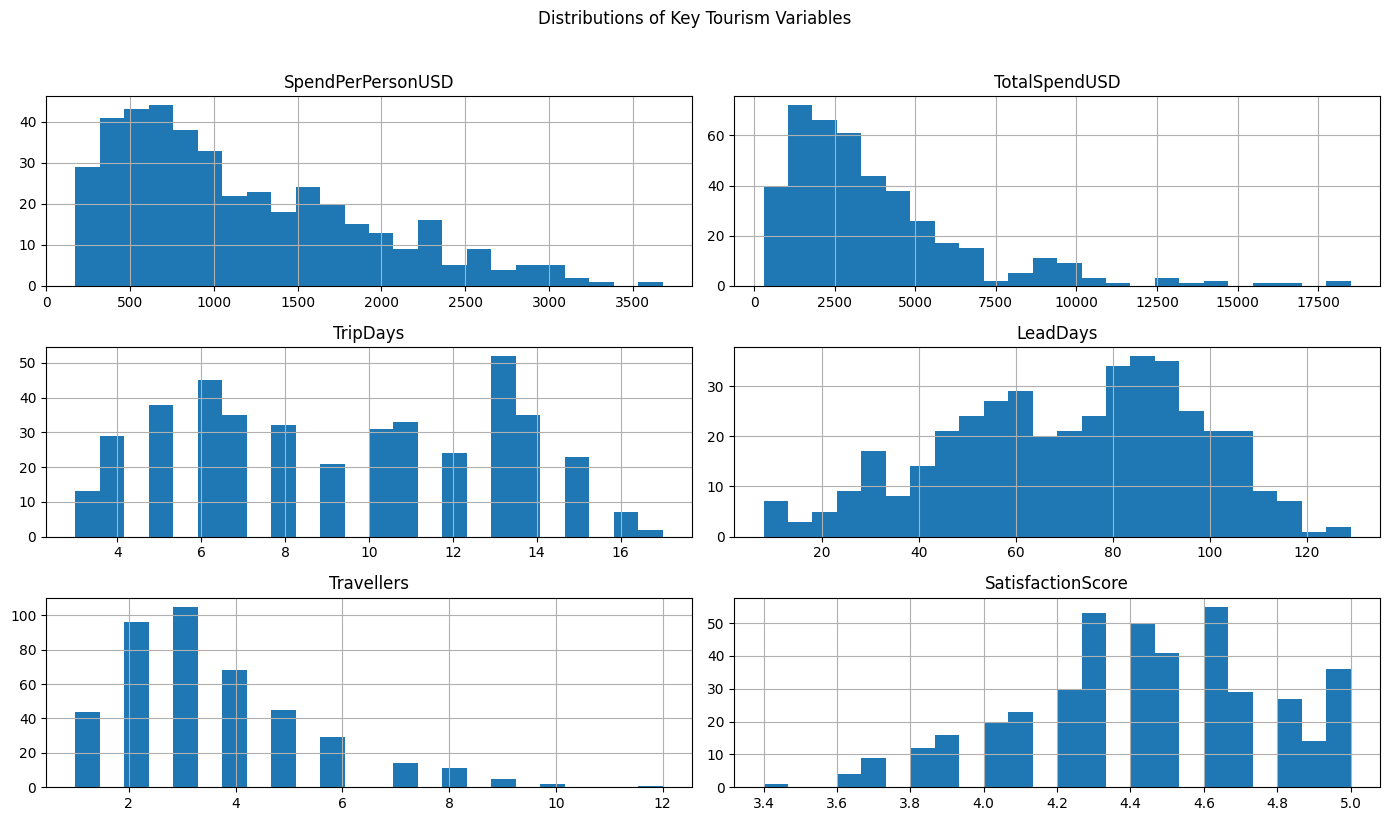

In [ ]:
# Distribution plots for important variables
PlotColumns = ['SpendPerPersonUSD','TotalSpendUSD','TripDays','LeadDays','Travellers','SatisfactionScore']
Data[PlotColumns].hist(figsize=(14,8), bins=24)
plt.suptitle('Distributions of Key Tourism Variables', y=1.02)
plt.tight_layout()
plt.show()

## Question 1: Distribution interpretation

Look at the histograms above.

**1. Which variables look approximately symmetric?**


From the histograms, the variables that appear approximately symmetric are:

LeadDays – The values are distributed around the center with a roughly balanced shape.
SatisfactionScore – The distribution is fairly balanced around the average score, although it is slightly concentrated at higher values.


**2. Which variables look skewed?**

The following variables appear to be skewed:

SpendPerPersonUSD – Positively (right) skewed, with most bookings having lower spending and a few customers spending much more.
TotalSpendUSD – Strongly positively skewed due to a small number of very high total spending values.
Travellers – Right skewed, as most bookings involve small groups while only a few have many travellers.
TripDays – Slightly right skewed, with most trips lasting a moderate number of days and fewer long-duration trips.


**3. Why is it useful to inspect distributions before regression?**

Inspecting data distributions before regression helps identify skewness, outliers, and unusual patterns that may affect the performance and assumptions of a regression model. It also helps determine whether variables require preprocessing, such as transformations or outlier treatment, to improve model accuracy and reliability.



# Part 2: Relationships before regression

Regression is not just a formula. It is based on relationships between variables.

We now inspect how SpendPerPersonUSD relates to possible predictors.

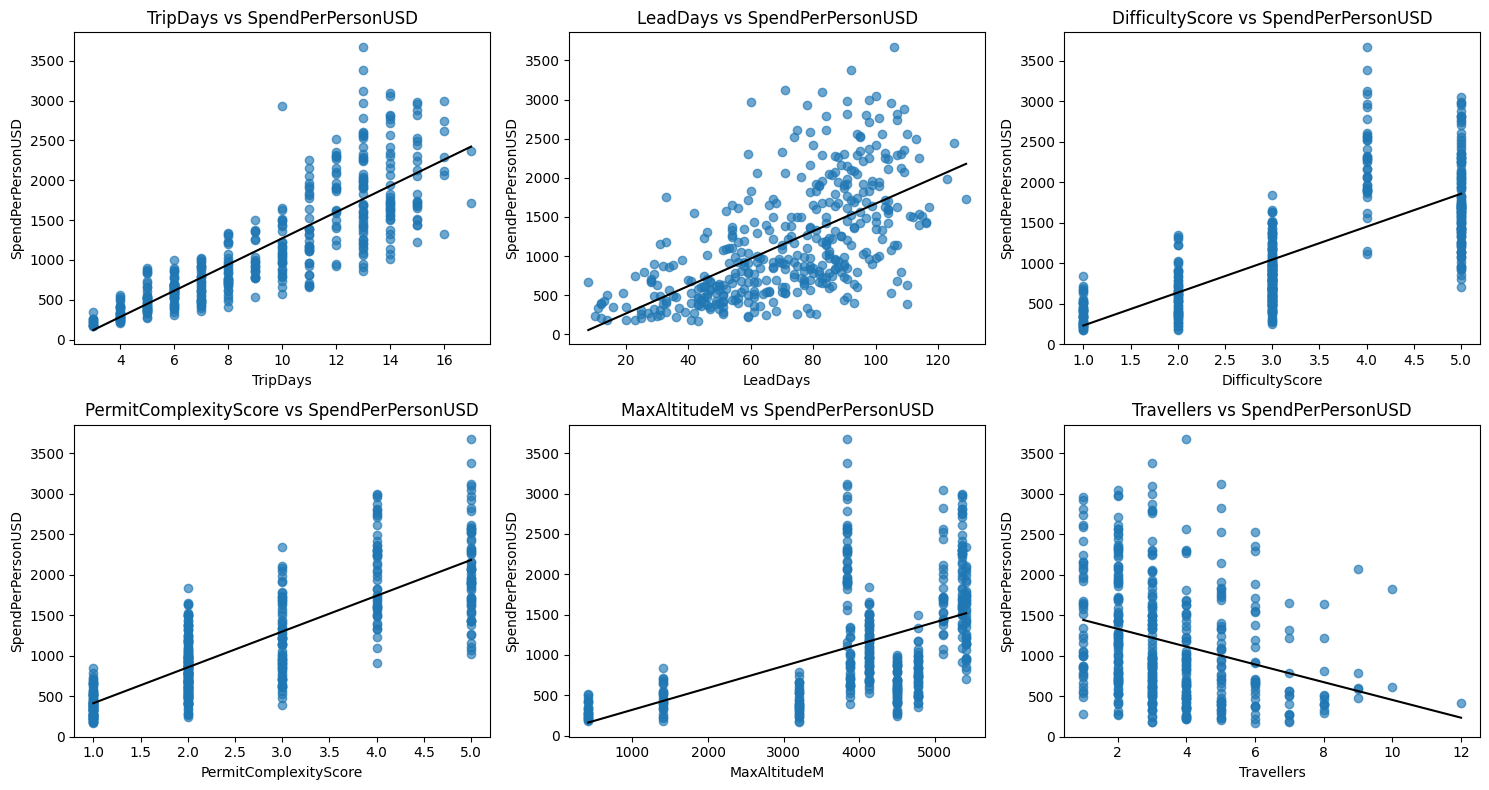

In [ ]:
# Scatterplots for numerical predictors
fig, axes = plt.subplots(2, 3, figsize=(15,8))
Pairs = [
    ('TripDays','SpendPerPersonUSD'),
    ('LeadDays','SpendPerPersonUSD'),
    ('DifficultyScore','SpendPerPersonUSD'),
    ('PermitComplexityScore','SpendPerPersonUSD'),
    ('MaxAltitudeM','SpendPerPersonUSD'),
    ('Travellers','SpendPerPersonUSD')
]
for ax, (xcol, ycol) in zip(axes.flatten(), Pairs):
    ax.scatter(Data[xcol], Data[ycol], alpha=0.65)
    Slope, Intercept = np.polyfit(Data[xcol], Data[ycol], 1)
    Xline = np.linspace(Data[xcol].min(), Data[xcol].max(), 100)
    ax.plot(Xline, Intercept + Slope * Xline, color='black')
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(xcol + ' vs ' + ycol)
plt.tight_layout()
plt.show()

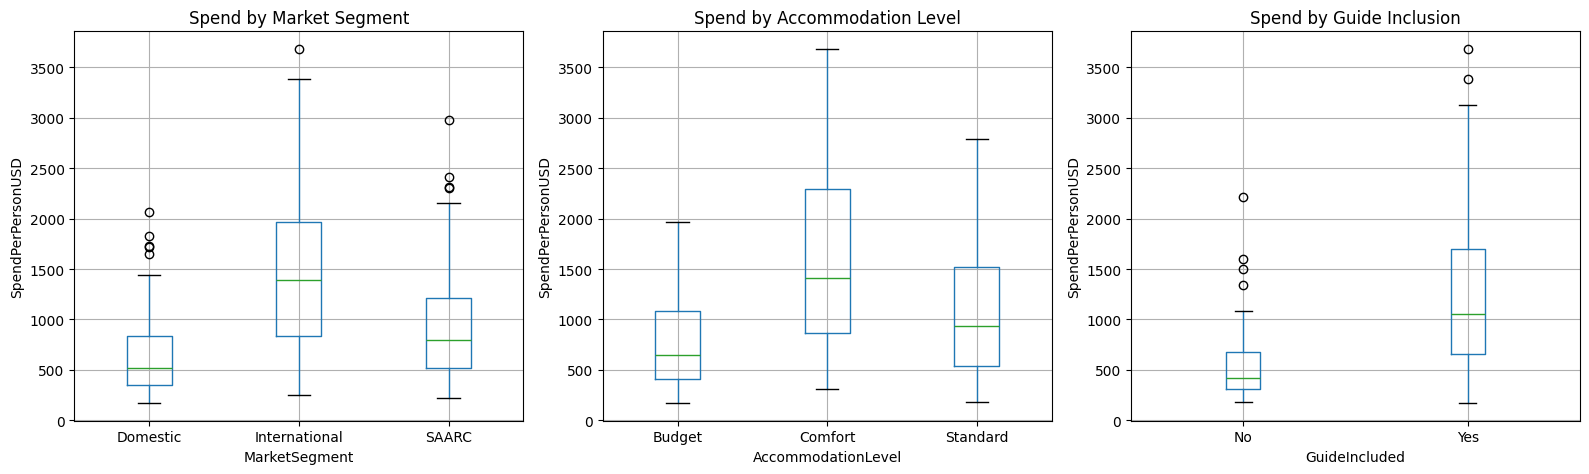

In [ ]:
# Boxplots for categorical predictors
fig, axes = plt.subplots(1, 3, figsize=(16,5))

Data.boxplot(column='SpendPerPersonUSD', by='MarketSegment', ax=axes[0])
axes[0].set_title('Spend by Market Segment')
axes[0].set_xlabel('MarketSegment')
axes[0].set_ylabel('SpendPerPersonUSD')

Data.boxplot(column='SpendPerPersonUSD', by='AccommodationLevel', ax=axes[1])
axes[1].set_title('Spend by Accommodation Level')
axes[1].set_xlabel('AccommodationLevel')
axes[1].set_ylabel('SpendPerPersonUSD')

Data.boxplot(column='SpendPerPersonUSD', by='GuideIncluded', ax=axes[2])
axes[2].set_title('Spend by Guide Inclusion')
axes[2].set_xlabel('GuideIncluded')
axes[2].set_ylabel('SpendPerPersonUSD')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Question 2: Relationship interpretation

Identify three variables that appear related to SpendPerPersonUSD.

For each variable, briefly explain whether the relationship is positive, negative, weak, strong, or group based.

Answer:

1. TripDays → SpendPerPersonUSD (Positive Relationship)
The scatter plot shows a clear positive relationship between TripDays and SpendPerPersonUSD. As the number of trip days increases, the spending per person also increases. This appears to be a fairly strong positive relationship because the trend line slopes upward and most points follow the same pattern.

2. LeadDays → SpendPerPersonUSD (Moderate Positive Relationship)
There is a moderate positive relationship between LeadDays and SpendPerPersonUSD. Customers who book their trips earlier generally spend more per person. Although the data points are more scattered than TripDays, the upward trend line indicates a positive association.

3. AccommodationLevel → SpendPerPersonUSD (Group-Based Relationship)
The boxplot shows a group-based relationship between AccommodationLevel and SpendPerPersonUSD. Travellers staying in Comfort accommodation have the highest median spending, followed by Standard, while Budget travellers spend the least. This suggests that the accommodation category has a noticeable effect on customer spending.

# Part 3: Confidence interval for average spend

A sample mean is only a point estimate. A confidence interval shows uncertainty around that estimate.

For a 95 percent confidence interval for a mean:

$$
\bar{x}\pm1.96\frac{s}{\sqrt{n}}
$$

In [ ]:
# Confidence interval for mean SpendPerPersonUSD
Y = Data['SpendPerPersonUSD']
MeanY = Y.mean()
StdY = Y.std(ddof=1)
N = Y.shape[0]
SEY = StdY / np.sqrt(N)
CI_low = MeanY - 1.96 * SEY
CI_high = MeanY + 1.96 * SEY

print('Mean SpendPerPersonUSD:', round(MeanY,2))
print('Standard deviation:', round(StdY,2))
print('Sample size:', N)
print('Standard error:', round(SEY,2))
print('95 percent CI:', round(CI_low,2), 'to', round(CI_high,2))

Mean SpendPerPersonUSD: 1162.71
Standard deviation: 731.13
Sample size: 420
Standard error: 35.68
95 percent CI: 1092.79 to 1232.64


## Question 3: Confidence interval interpretation

Interpret the confidence interval in simple business language.

Do not just repeat the numbers. Explain what the range means for the tourism company.

Answer:

The 95% confidence interval suggests that the true average amount spent per person by customers is likely to fall within this range. This gives the tourism company confidence that the average customer spending is not just based on this sample but is a good estimate of the overall customer population.

For business planning, this means the company can expect the average spending per customer to be around this range when forecasting revenue, setting package prices, and preparing budgets. Since the confidence interval is relatively narrow, the estimate is considered reliable and indicates that the sample provides a good representation of customer spending.

The company can use this information to make better financial decisions and estimate future income with greater confidence.

# Part 4: Comparing two groups with confidence intervals and t test

Business question:

Do international tourists spend more per person than domestic tourists?

Null hypothesis:

$$
H_0:\mu_{International}-\mu_{Domestic}=0
$$

Alternative hypothesis:

$$
H_1:\mu_{International}-\mu_{Domestic}\neq0
$$

In [ ]:
# Compare spend between International and Domestic customers
International = Data.loc[Data['MarketSegment'] == 'International', 'SpendPerPersonUSD']
Domestic = Data.loc[Data['MarketSegment'] == 'Domestic', 'SpendPerPersonUSD']

MeanInternational = International.mean()
MeanDomestic = Domestic.mean()
Diff = MeanInternational - MeanDomestic
SEdiff = np.sqrt(International.var(ddof=1)/len(International) + Domestic.var(ddof=1)/len(Domestic))
CIdiffLow = Diff - 1.96 * SEdiff
CIdiffHigh = Diff + 1.96 * SEdiff

Tstat, Pvalue = stats.ttest_ind(International, Domestic, equal_var=False)

print('International mean:', round(MeanInternational,2), 'n =', len(International))
print('Domestic mean:', round(MeanDomestic,2), 'n =', len(Domestic))
print('Difference:', round(Diff,2))
print('Standard error of difference:', round(SEdiff,2))
print('95 percent CI for difference:', round(CIdiffLow,2), 'to', round(CIdiffHigh,2))
print('t statistic:', round(Tstat,3))
print('p value:', round(Pvalue,6))

International mean: 1456.1 n = 240
Domestic mean: 647.05 n = 102
Difference: 809.06
Standard error of difference: 62.82
95 percent CI for difference: 685.92 to 932.19
t statistic: 12.878
p value: 0.0


## Question 4: Hypothesis test interpretation

Use the t statistic, p value, and confidence interval to answer:

1. Is there statistical evidence that international and domestic customers differ in spend per person?
2. Does the confidence interval include zero?
3. Is the result practically meaningful for the tourism company?

Answer:

Yes, there is strong statistical evidence that international and domestic customers differ in their average spending per person. The t-statistic is 12.878, which is a large value, and the p-value is 0.000 (less than 0.05). This means we reject the null hypothesis and conclude that the difference in average spending is statistically significant.

The 95% confidence interval (685.92 to 932.19) does not include zero, which further confirms that there is a real difference between the two groups. Since the entire interval is positive, it indicates that international tourists spend more per person than domestic tourists.

This result is also practically meaningful for the tourism company. International tourists spend about USD 809 more per person on average than domestic tourists. The company can use this information to design premium travel packages, target international customers with marketing campaigns, and focus on services that increase revenue from higher-spending visitors.

# Part 5: Multiple linear regression

Now we build a multiple linear regression model for:

$$
Y=\text{SpendPerPersonUSD}
$$

The model uses several predictors together.

General form:

$$
y_i=\beta_0+\beta_1x_{i1}+\beta_2x_{i2}+\cdots+\beta_px_{ip}+\varepsilon_i
$$

We will include numerical and categorical predictors.

In [ ]:
# Multiple linear regression using statsmodels formula API
Formula = "SpendPerPersonUSD ~ TripDays + LeadDays + Travellers + DifficultyScore + PermitComplexityScore + GuideIncluded + AccommodationLevel + MarketSegment + Season + BookingChannel"
OLSModel = smf.ols(Formula, data=Data).fit()
OLSModel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      SpendPerPersonUSD   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     216.5
Date:                Wed, 15 Jul 2026   Prob (F-statistic):          1.84e-186
Time:                        17:02:46   Log-Likelihood:                -2890.3
No. Observations:                 420   AIC:                             5815.
Df Residuals:                     403   BIC:                             5883.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         -519.6728     82.103     -6.330      0.000    -681.077    -358.269
GuideIncluded[T.Yes]                91.8418     38.704      2.373      0.018      15.754     167.929
AccommodationLevel[T.Comfort]      516.8738     35.940     14.382      0.000     446.221     587.527
AccommodationLevel[T.Standard]     140.6048     32.503      4.326      0.000      76.708     204.502
MarketSegment[T.International]     340.6649     52.106      6.538      0.000     238.231     443.098
MarketSegment[T.SAARC]              97.1121     39.822      2.439      0.015      18.827     175.397
Season[T.Monsoon]                 -172.2103     40.073     -4.297      0.000    -250.988     -93.432
Season[T.Spring]                   -24.6799     29.409     -0.839      0.402     -82.494      33.134
Season[T.Winter]                  -160.6328     34.136     -4.706      0.000    -227.739     -93.527
BookingChannel[T.Direct]           -72.0351     45.696     -1.576      0.116    -161.868      17.798
BookingChannel[T.OnlinePlatform]   -43.6346     50.284     -0.868      0.386    -142.486      55.217
BookingChannel[T.TravelAgent]      -46.1919     45.221     -1.021      0.308    -135.091      42.708
TripDays                           105.3819      7.564     13.932      0.000      90.512     120.252
LeadDays                            -0.2405      1.002     -0.240      0.810      -2.210       1.729
Travellers                           8.5569      7.209      1.187      0.236      -5.615      22.729
DifficultyScore                   -131.3376     21.306     -6.164      0.000    -173.223     -89.453
PermitComplexityScore              263.2602     15.777     16.686      0.000     232.244     294.277
==============================================================================
Omnibus:                       39.779   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               79.194
Skew:                           0.546   Prob(JB):                     6.36e-18
Kurtosis:                       4.826   Cond. No.                         648.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Question 5: Regression output interpretation

Look at the regression summary.

Answer the following:

1. What is the dependent variable?

The dependent variable is SpendPerPersonUSD. This is the variable that the regression model is trying to predict using the other predictor variables.


2. Which predictors appear statistically significant at the 5 percent level?

The predictors with p-values less than 0.05 are statistically significant:

GuideIncluded (Yes)
AccommodationLevel (Comfort)
AccommodationLevel (Standard)
MarketSegment (International)
MarketSegment (SAARC)
Season (Monsoon)
Season (Winter)
TripDays
DifficultyScore
PermitComplexityScore

These variables have a statistically significant effect on SpendPerPersonUSD.


3. Choose one significant numerical predictor and explain its coefficient.

TripDays is a significant numerical predictor with a coefficient of approximately 105.38.

This means that for each additional day of the trip, the average spending per person increases by about USD 105, assuming all other variables remain constant. This suggests that longer trips generally result in higher customer spending.


4. Choose one categorical predictor and explain how to interpret it relative to the reference category.

MarketSegment (International) is a significant categorical predictor with a coefficient of approximately 340.66.

This means that international tourists spend about USD 341 more per person than the reference group (Domestic tourists), after controlling for all other variables in the model. This indicates that international customers contribute higher revenue than domestic customers.


5. What does R squared tell us here?

The R-squared value is 0.896, which means the regression model explains approximately 89.6% of the variation in SpendPerPersonUSD. This indicates that the model fits the data very well and that the selected predictor variables explain most of the differences in customer spending.



# Part 6: How p values appear inside regression

In regression, each coefficient has a hypothesis test.

For predictor j:

$$
H_0:\beta_j=0
$$

$$
H_1:\beta_j\neq0
$$

The t statistic is:

$$
t=\frac{b_j-0}{SE(b_j)}
$$

A small p value suggests that the predictor is statistically associated with the outcome, after controlling for other variables in the model.

In [ ]:
# Extract coefficient table in a cleaner format
CoefTable = pd.DataFrame({
    'Coefficient': OLSModel.params,
    'StandardError': OLSModel.bse,
    'tStatistic': OLSModel.tvalues,
    'pValue': OLSModel.pvalues,
    'CILow': OLSModel.conf_int()[0],
    'CIHigh': OLSModel.conf_int()[1]
})
CoefTable.round(4)

,Coefficient,StandardError,tStatistic,pValue,CILow,CIHigh
Intercept,-519.6728,82.1031,-6.3295,0.0000,-681.0767,-358.2689
GuideIncluded[T.Yes],91.8418,38.7042,2.3729,0.0181,15.7545,167.9291
AccommodationLevel[T.Comfort],516.8738,35.9398,14.3816,0.0000,446.2209,587.5268
AccommodationLevel[T.Standard],140.6048,32.5032,4.3259,0.0000,76.7078,204.5018
MarketSegment[T.International],340.6649,52.1060,6.5379,0.0000,238.2315,443.0983
MarketSegment[T.SAARC],97.1121,39.8222,2.4386,0.0152,18.8270,175.3973
Season[T.Monsoon],-172.2103,40.0729,-4.2974,0.0000,-250.9884,-93.4322
Season[T.Spring],-24.6799,29.4088,-0.8392,0.4019,-82.4937,33.1338
Season[T.Winter],-160.6328,34.1356,-4.7057,0.0000,-227.7390,-93.5267
BookingChannel[T.Direct],-72.0351,45.6964,-1.5764,0.1157,-161.8682,17.7979


## Question 6: Coefficient p value analysis

Choose two predictors from the coefficient table.

For each predictor, write:

- coefficient value
- p value
- whether it is statistically significant
- what it means in business language
- whether it is practically important

Answer:

**Predictor 1: TripDays**
Coefficient value: 105.3819

p-value: 0.0000

Statistically significant?
 Yes, because the p-value is less than 0.05.
Business meaning: For every additional day of the trip, the average spending per person increases by approximately USD 105.38, while keeping all other variables constant.

Practically important?
Yes. This is a large increase in spending, so encouraging longer trips could help the tourism company generate more revenue.


**Predictor 2: MarketSegment (International)**
Coefficient value: 340.6649

p-value: 0.0000

Statistically significant?
Yes, because the p-value is less than 0.05.
Business meaning: International tourists spend about USD 340.66 more per person than the reference group (Domestic tourists), after accounting for the other variables in the model.

Practically important?
Yes. The large difference in spending suggests that attracting more international tourists could significantly increase the company's revenue.

# Part 7: Train test split and prediction error

Regression output tells us about relationships in the training data.

But prediction needs to be tested on data not used to train the model.

We now use a train test split.

In [ ]:
# Prepare data for train test modelling using one hot encoding
ModelColumns = ['TripDays','LeadDays','Travellers','DifficultyScore','PermitComplexityScore','GuideIncluded','AccommodationLevel','MarketSegment','Season','BookingChannel']
X = Data[ModelColumns]
y = Data['SpendPerPersonUSD']

Xencoded = pd.get_dummies(X, drop_first=True).astype(float)
Xtrain, Xtest, ytrain, ytest = train_test_split(Xencoded, y, test_size=0.25, random_state=42)

# Fit statsmodels on training set for prediction
XtrainConst = sm.add_constant(Xtrain)
XtestConst = sm.add_constant(Xtest, has_constant='add')
TrainModel = sm.OLS(ytrain, XtrainConst).fit()
Pred = TrainModel.predict(XtestConst)

MAE = mean_absolute_error(ytest, Pred)
RMSE = np.sqrt(mean_squared_error(ytest, Pred))
R2test = r2_score(ytest, Pred)

print('Test MAE:', round(MAE,2))
print('Test RMSE:', round(RMSE,2))
print('Test R squared:', round(R2test,3))

Test MAE: 189.31
Test RMSE: 263.71
Test R squared: 0.877


## Question 7: Test error interpretation

Interpret the test error values.

1. What does MAE mean in this context?

The Mean Absolute Error (MAE) is 189.31, which means that, on average, the model's predicted SpendPerPersonUSD differs from the actual spending by about USD 189. This shows the typical prediction error without considering whether the prediction is higher or lower than the actual value.


2. What does RMSE mean in this context?

The Root Mean Squared Error (RMSE) is 263.71, meaning the model's predictions are, on average, about USD 264 away from the actual spending when larger errors are given more weight. Since RMSE is higher than MAE, it suggests that a few predictions have relatively larger errors.


3. Is the error small or large compared with typical SpendPerPersonUSD?

The average SpendPerPersonUSD is approximately USD 1,162.71. Compared to this, an MAE of USD 189.31 is about 16% of the average spending, which is relatively small. Therefore, the model's prediction error is acceptable for this dataset.


4. Would this model be useful for rough business planning?

Yes. The model would be useful for rough business planning and forecasting because it has a high test R² of 0.877, meaning it explains about 87.7% of the variation in customer spending. Although individual predictions may differ by around USD 189–264, the model is accurate enough to support budgeting, pricing decisions, marketing strategies, and estimating customer spending trends.



# Part 8: Residual error analysis

A residual is the prediction error for one observation.

$$
e_i=y_i-\hat{y}_i
$$

Residual plots help us see whether errors look random or whether the model is missing a pattern.

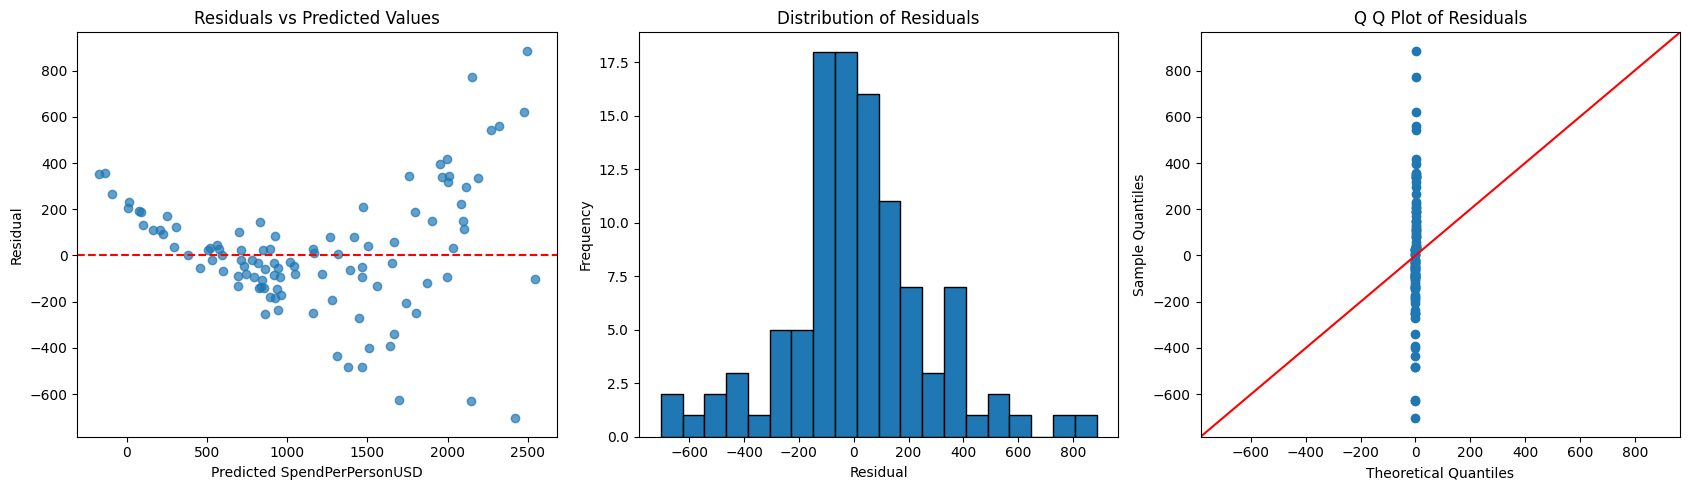

In [ ]:
# Residual analysis on test set
Residuals = ytest - Pred

fig, axes = plt.subplots(1, 3, figsize=(17,5))

axes[0].scatter(Pred, Residuals, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted SpendPerPersonUSD')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted Values')

axes[1].hist(Residuals, bins=20, edgecolor='black')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

sm.qqplot(Residuals, line='45', ax=axes[2])
axes[2].set_title('Q Q Plot of Residuals')

plt.tight_layout()
plt.show()

## Question 8: Residual analysis

Look at the residual plots.

1. Do residuals appear randomly scattered around zero?

Not completely. Although many residuals are centered around the zero line, the residual plot shows a curved pattern rather than a random scatter. This suggests that the model does not capture all the relationships in the data.


2. Are there signs of non-linearity or changing variance?

Yes. The residual plot indicates both non-linearity and changing variance (heteroscedasticity). The spread of residuals becomes larger as the predicted spending increases, meaning the prediction errors are greater for customers with higher spending.


3. Are residuals approximately normal?

The histogram of residuals is roughly bell-shaped and centered near zero, but it is slightly skewed and contains some extreme values. The Q-Q plot also shows deviations from the reference line, especially at the ends, indicating that the residuals are only approximately normal.


4. What model improvements might be considered?

The model could be improved by:

1. Adding non-linear terms (such as polynomial features) to better capture curved relationships.

2. Including interaction effects between important variables.

3. Investigating and handling outliers that may affect the model.

4. Applying transformations (such as a log transformation of the target variable) if appropriate to reduce skewness and stabilize variance.

5. Testing more advanced regression models, such as Random Forest or Gradient Boosting, if higher prediction accuracy is required.


# Part 9: Statistical significance vs practical significance

A p value can tell us whether a predictor is statistically associated with the outcome.

But practical significance asks whether the effect is large enough to matter.

Example:

A coefficient may have:

$$
p<0.05
$$

but the effect may be too small to change a business decision.

In [ ]:
# Show statistically significant predictors sorted by absolute coefficient size
Sig = CoefTable[CoefTable['pValue'] < 0.05].copy()
Sig['AbsCoefficient'] = Sig['Coefficient'].abs()
Sig.sort_values('AbsCoefficient', ascending=False).round(3)

,Coefficient,StandardError,tStatistic,pValue,CILow,CIHigh,AbsCoefficient
Intercept,-519.673,82.103,-6.330,0.000,-681.077,-358.269,519.673
AccommodationLevel[T.Comfort],516.874,35.940,14.382,0.000,446.221,587.527,516.874
MarketSegment[T.International],340.665,52.106,6.538,0.000,238.231,443.098,340.665
PermitComplexityScore,263.260,15.777,16.686,0.000,232.244,294.277,263.260
Season[T.Monsoon],-172.210,40.073,-4.297,0.000,-250.988,-93.432,172.210
Season[T.Winter],-160.633,34.136,-4.706,0.000,-227.739,-93.527,160.633
AccommodationLevel[T.Standard],140.605,32.503,4.326,0.000,76.708,204.502,140.605
DifficultyScore,-131.338,21.306,-6.164,0.000,-173.223,-89.453,131.338
TripDays,105.382,7.564,13.932,0.000,90.512,120.252,105.382
MarketSegment[T.SAARC],97.112,39.822,2.439,0.015,18.827,175.397,97.112


## Question 9: Significance discussion

From the statistically significant predictors:

1. Which predictor seems most practically important?

Among the statistically significant predictors, AccommodationLevel (Comfort) appears to be the most practically important because it has one of the largest positive coefficients (516.87). This means customers choosing Comfort accommodation spend about USD 517 more per person than those in the reference accommodation category, making it highly relevant for business decisions.


2. Which predictor may be statistically significant but less important in business terms?

GuideIncluded (Yes) is statistically significant (p = 0.018), but its coefficient is relatively small (91.84). Although there is evidence that having a guide increases spending, the increase is much smaller than the effects of accommodation level or market segment. Therefore, it may have less practical impact on business decisions.


3. Why should we not rely only on p values?

A p-value only tells us whether a relationship is statistically significant; it does not indicate how large or important the effect is. A predictor can have a very small p-value but only a small impact on spending. Business decisions should consider both statistical significance (p-value) and practical significance (coefficient size and business impact). Predictors with larger effects are generally more useful for improving revenue and making strategic decisions.
